# 第10章 Pendulum：行動が連続の値の環境

第7〜9章の環境では、行動は「左へ押す・右へ押す」のように、いくつかの中から1つを選ぶものでした。この章の **Pendulum** では、振り子の軸にかける力（トルク）を、-2〜2 の間の **好きな値** で選びます。行動が連続の値になると、第7章の DQN のように「行動ごとの Q 値を並べて、一番大きいものを選ぶ」ことが、そのままではできません。

まず、トルクをいくつかの段階に区切って、DQN で解いてみます。次に、行動が連続の値のまま扱える **SAC** を Stable-Baselines3（SB3）で動かして楽しみます。そのあと、同じ系統のもっとも基本的な手法である **DDPG** を、PyTorch で書いた短いサンプルで読みます。最後に、SB3 の SAC・TD3・DDPG と、区切った DQN の結果を並べます。

- **前提**: [第9章 MountainCar／Acrobot](../ch09_mountaincar_acrobot/ch09_mountaincar_acrobot.ipynb)を終えていること。DQN のサンプル（[第7章](../ch07_cartpole_dqn/ch07_cartpole_dqn.ipynb)）と Actor-Critic（[第8章](../ch08_cartpole_reinforce/ch08_cartpole_reinforce.ipynb)）を読んでいると、6節が読みやすくなります
- **所要の目安**: 実行は CPU で 15 分ほど（著者の環境で、Notebook 全体を上から実行して約 10〜14 分）
- **使う装置**: CPU で十分です（この章では GPU を使いません）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、Stable-Baselines3 2.9.0、PyTorch 2.14.1）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。学習にかかる時間は、パソコンによって変わります。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. 行動が連続の値の環境（`Box` の行動の空間）では、DQN をそのままでは使えない理由と、行動を区切るという回り道を説明できる
2. SB3 の SAC を RL Zoo の調整済みのハイパーパラメータで学習させ、成績と振り子を振り上げる様子を見られる
3. DDPG のサンプルで、Actor（行動を出すネットワーク）と Critic（Q 値を見積もるネットワーク）を、それぞれどの損失で学習させているかを示せる
4. SAC・TD3・DDPG と区切った DQN の結果を、測った値で比べられる

完了条件は、この Notebook を上から最後まで実行して、5節の SAC の **最後の時点のモデル** が、Pendulum-v1 の 100 回の評価で報酬の合計の平均 **-200 以上** になることです。Gymnasium 1.3.0 には、Pendulum-v1 の「解けた」の目安（`reward_threshold`）が登録されていません。-200 は、3節のでたらめな行動（平均 -1229.3）と、著者が試した手法の成績（seed 0〜4 で -155〜-174 ほど。4節・7節）を見て、著者が決めた目安です。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | 環境を知る：観測・連続の値の行動・報酬 | でたらめな行動の成績 |
| 4節 | 回り道：トルクを区切って DQN で解く | 成績、区切る段階の数による違い |
| 5節 | 動かして楽しむ：SB3 の SAC | 成績、振り子を振り上げる様子 |
| 6節 | 読む：PyTorch の DDPG のサンプル | Actor と Critic の損失、ターゲットネットワークの更新 |
| 7節 | 比べる：SAC・TD3・DDPG・区切った DQN | 学習中の評価、seed を変えた成績 |
| 8節 | 遊んでみる | 試してみる設定 |

SAC・TD3・DDPG は、概要資料の[強化学習の手法の地図](../../overview/rl.md)で「ニューラルネットワークで近似する」領域の、DQN から続く **方策オフ** の流れの先にある手法です。どれも、行動を出す Actor と、Q 値を見積もる Critic を組み合わせた **Actor-Critic** の手法です（第8章の A2C は、方策オンの Actor-Critic でした）。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う関数を用意します。

In [1]:
import copy
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image
from stable_baselines3 import DQN, SAC
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from torch import nn

torch.set_num_threads(1)  # 計算に使うスレッドを1つにする（著者が seed を変えて測ったときの条件とそろえるため）

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


def make_pendulum():
    return gym.make("Pendulum-v1")


# make_env() で作った環境で、方策 policy（観測 → 行動を返す関数）で episodes 回遊ばせ、報酬の合計の平均と標準偏差を返す
def evaluate(policy, episodes=100, seed=100, make_env=make_pendulum):
    env = make_env()
    totals = np.zeros(episodes)
    for i in range(episodes):
        observation, info = env.reset(seed=seed if i == 0 else None)
        while True:
            observation, reward, terminated, truncated, info = env.step(policy(observation))
            totals[i] += reward
            if terminated or truncated:
                break
    return totals.mean(), totals.std()


# 方策 policy で1エピソード遊ばせ、every ステップごとの (ステップ数, 絵) の一覧を返す（絵は Gymnasium の描画）
def record_episode(policy, seed, every):
    env = gym.make("Pendulum-v1", render_mode="rgb_array")
    observation, info = env.reset(seed=seed)
    shots = [(0, env.render())]
    steps = 0
    while True:
        observation, reward, terminated, truncated, info = env.step(policy(observation))
        steps += 1
        if steps % every == 0 or terminated or truncated:
            shots.append((steps, env.render()))
        if terminated or truncated:
            return shots


# SB3 のモデルで、決まった行動（一番よいと見積もった行動）を選ぶ方策を返す
def sb3_policy(model):
    return lambda observation: model.predict(observation, deterministic=True)[0]

関数の説明:

- `evaluate` は、第9章と同じく、最初の `reset` にだけ `seed=100` を渡して 100 回遊ばせます。4節で行動を区切った環境でも使えるように、環境を作る関数 `make_env` を渡せるようにしました
- `record_episode` と `sb3_policy` は、第9章と同じ関数です（Pendulum の行動は小数の配列なので、`sb3_policy` は `int` に直さずにそのまま返します）

## 3. 環境を知る：観測・連続の値の行動・報酬

### 3-1. 観測と行動の空間

**Pendulum-v1** は、軸のまわりに回る1本の振り子を、真上に立てて保つ環境です。振り子は、でたらめな向き（-π〜π の角度）と、でたらめな角速度（-1〜1）から始まります（Gymnasium 1.3.0 の `pendulum.py` の環境の説明）。軸にかけられるトルクは弱く、著者が確かめたところ、真下で止まった状態から最大のトルク 2.0 をかけ続けても、振り子は真下から 49° ほどまでしか上がりませんでした。真上まで上げるには、揺らして勢いをつける必要があります。

In [2]:
env = make_pendulum()
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)
env.action_space.seed(0)
print("でたらめな行動の例:", [env.action_space.sample() for _ in range(3)])

観測の空間: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
行動の空間: Box(-2.0, 2.0, (1,), float32)
でたらめな行動の例: [array([0.54784673], dtype=float32), array([-0.92085314], dtype=float32), array([-1.836106], dtype=float32)]


**期待する結果**（上の出力の読み方）: 観測の空間は、下限が [-1, -1, -8]、上限が [1, 1, 8] の、3つの小数の `Box` です。行動の空間は、-2.0〜2.0 の小数1つの `Box`（形は `(1,)`）です。でたらめな行動の例は、0.548、-0.921、-1.836 のような小数で、どれも長さ1の配列です。

- 観測: 振り子の角度 θ（真上が 0）の cos と sin、角速度（-8〜8）の、3つの小数
- 行動: 軸にかけるトルク。-2.0〜2.0 の間の小数を1つ、長さ1の配列で渡します
- 報酬: 1ステップごとに、-(θ² + 0.1 × 角速度² + 0.001 × トルク²)。θ は -π〜π に直した角度です。真上で止まっていて、トルクをかけていないときが一番大きく、0 になります
- 終わり方: 途中で終わる（`terminated`）ことはなく、200 ステップで打ち切られます（`truncated`）

第7〜9章の環境の行動の空間は `Discrete`（0、1、2 のような番号）でした。

第9章の MountainCar と違い、**報酬は毎ステップ、振り子の状態に応じて変わります**。真上に近いほど、ゆっくり回っているほど、報酬は 0 に近づきます。

### 3-2. でたらめな行動とトルク 0 で 100 回ずつ遊ぶ

In [3]:
env = make_pendulum()
env.action_space.seed(0)
for name, policy in [("でたらめな行動", lambda observation: env.action_space.sample()),
                     ("いつもトルク 0", lambda observation: np.array([0.0], dtype=np.float32))]:
    mean, std = evaluate(policy)
    print(f"{name}: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

でたらめな行動: 報酬の合計の平均 -1229.3、標準偏差 293.2


いつもトルク 0: 報酬の合計の平均 -1243.0、標準偏差 344.2


**期待する結果**（上の出力の読み方）: でたらめな行動の報酬の合計の平均は -1229.3（標準偏差 293.2）、いつもトルク 0 では -1243.0（標準偏差 344.2）で、どちらも -1200 あたりです。

## 4. 回り道：トルクを区切って DQN で解く

### 4-1. 行動を区切るラッパー

第7章の DQN は、ネットワークが行動ごとの Q 値を出し、一番大きい行動を選びました。この形は、行動の数が決まっていないと作れません。SB3 の `DQN` も、行動の空間が `Discrete`（いくつかの中から1つ）の環境にしか使えません（概要資料の [Stable-Baselines3](../../overview/sb3.md)）。

そこで、Gymnasium の **ラッパー**（環境を包んで、やり取りを書き換える仕組み。第2章）で、「行動の番号 → トルクの値」に直す層をかぶせます。たとえば 5 段階なら、番号 0〜4 を、トルク -2.0、-1.0、0.0、1.0、2.0 に直します。DQN から見ると、行動が5つの環境になります。

DQN のハイパーパラメータは、RL Zoo の `dqn.yml` に Pendulum-v1 の項目が無いので、著者が決めた値です。著者の環境では 70 秒ほどかかりました。

In [4]:
# 行動の番号（0〜n_torques-1）を、-2.0〜2.0 を等間隔に区切ったトルクの値に直すラッパー
class DiscreteTorque(gym.ActionWrapper):
    def __init__(self, env, n_torques):
        super().__init__(env)
        self.torques = np.linspace(-2.0, 2.0, n_torques)
        self.action_space = gym.spaces.Discrete(n_torques)

    def action(self, action):
        return np.array([self.torques[action]], dtype=np.float32)


N_TORQUES = 5
make_discrete = lambda: DiscreteTorque(make_pendulum(), N_TORQUES)
print("区切ったトルク:", make_discrete().torques)
print("区切った環境の行動の空間:", make_discrete().action_space)

# 著者が決めた DQN のハイパーパラメータ（RL Zoo に Pendulum-v1 の値が無いため）
DQN_PARAMS = dict(
    learning_rate=1e-3, buffer_size=50_000, learning_starts=1000, gamma=0.98, target_update_interval=500,
    train_freq=1, gradient_steps=1, exploration_fraction=0.2, exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[256, 256]),
)
dqn_model = DQN("MlpPolicy", Monitor(make_discrete()), seed=0, device="cpu", **DQN_PARAMS)
# 1,000 ステップごとに 10 回遊ばせて評価し、記録を checkpoints/ に保存する（7節の図に使う）
dqn_callback = EvalCallback(make_vec_env(make_discrete, n_envs=1, seed=200), n_eval_episodes=10, eval_freq=1000,
                            log_path="checkpoints/dqn_pendulum", verbose=0)
start = time.perf_counter()
dqn_model.learn(total_timesteps=20_000, callback=dqn_callback)
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
mean, std = evaluate(lambda observation: int(dqn_model.predict(observation, deterministic=True)[0]), make_env=make_discrete)
print(f"最後の時点のモデル（トルク {N_TORQUES} 段階）: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

区切ったトルク: [-2. -1.  0.  1.  2.]
区切った環境の行動の空間: Discrete(5)


学習にかかった時間: 68 秒


最後の時点のモデル（トルク 5 段階）: 報酬の合計の平均 -161.4、標準偏差 83.7


**期待する結果**（上の出力の読み方）: 区切ったトルクは -2、-1、0、1、2 の5つで、区切った環境の行動の空間は `Discrete(5)` です。学習は著者の環境で 68 秒でした。最後の時点のモデルの報酬の合計の平均は -161.4（標準偏差 83.7）で、3-2節のでたらめな行動（-1229.3）よりずっと大きく、この章の目安の -200 を超えています。

著者が学習の seed を 0〜4 に変え、区切る段階の数（`N_TORQUES`）を変えて測った、最後の時点のモデルの成績は、次のとおりです（このセルと同じ設定と評価）。

| トルクの段階の数（`N_TORQUES`） | 区切ったトルク | 最後の時点の平均（seed 0〜4） |
|---|---|---|
| 2 | -2、2 | -162.2〜-174.0 |
| 3 | -2、0、2 | -162.5〜-165.8 |
| 5 | -2、-1、0、1、2 | -161.4〜-168.8 |
| 11 | -2.0、-1.6、…、2.0 | -163.8〜-170.6 |

この範囲では、段階の数による大きな差はありませんでした。トルクを -2 と 2 の2つだけにしても、どの seed でも -200 を超えました。

区切る方法には、限りもあります。行動が1つの値なら数段階に区切れば済みますが、行動が2つ・3つの値の組（ロボットの関節ごとのトルクなど）になると、組み合わせの数が掛け算で増えます。たとえば、6つの関節のトルクをそれぞれ 5 段階に区切ると、行動の数は 5⁶ = 15,625 になります。第12章の BipedalWalker の行動は、4つの値の組です（著者が Gymnasium 1.3.0 の `BipedalWalker-v3` の `action_space` を表示して確かめました）。

## 5. 動かして楽しむ：SB3 の SAC

### 5-1. 学習させる

行動が連続の値のまま扱える **SAC**（Soft Actor-Critic）を、SB3 で学習させます。ハイパーパラメータは、**RL Zoo** の Pendulum-v1 用の値です。RL Zoo の値は「20,000 ステップ学習する」「学習率を 0.001 にする」の2つで、ほかは SB3 の既定値です（出典は末尾）。

学習中の様子を見るために、`EvalCallback` で、1,000 ステップごとに 10 回遊ばせて評価し、その記録を `checkpoints` フォルダに保存します。著者の環境では 370〜640 秒ほどかかりました（この章で一番長いセルです）。

In [5]:
# RL Zoo（v2.9.0）の SAC の Pendulum-v1 用のハイパーパラメータ（出典は末尾）。書いていない設定は SB3 の既定値
sac_train_env = Monitor(make_pendulum())
sac_model = SAC("MlpPolicy", sac_train_env, learning_rate=1e-3, seed=0, device="cpu", tensorboard_log="logs")
sac_callback = EvalCallback(make_vec_env(make_pendulum, n_envs=1, seed=200), n_eval_episodes=10, eval_freq=1000,
                            log_path="checkpoints/sac_pendulum", verbose=0)
start = time.perf_counter()
sac_model.learn(total_timesteps=20_000, callback=sac_callback, tb_log_name="sac_pendulum")
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print("学習中のエピソードの数:", len(sac_train_env.get_episode_rewards()))
sac_evals = np.mean(sac_callback.evaluations_results, axis=1)
print("1,000 ステップごとの評価（10 回の平均）:", np.round(sac_evals, 1))

学習にかかった時間: 639 秒
学習中のエピソードの数: 100
1,000 ステップごとの評価（10 回の平均）: [-1545.4  -944.4  -362.3  -170.8  -130.5  -147.3  -190.8  -140.3  -145.3
  -138.2  -182.3  -162.7  -119.   -130.3  -117.2  -164.4  -156.2  -113.4
  -143.9  -187.4]


**期待する結果**（上の出力の読み方）: 学習は、この実行では 639 秒でした。20,000 ステップの間のエピソードは、ちょうど 100 回です。1,000 ステップごとの評価（10 回の平均）は、1,000 ステップで -1545.4、2,000 ステップで -944.4、3,000 ステップで -362.3 と上がり、4,000 ステップで -170.8 になりました。そのあとは、最後の 20,000 ステップまで、-113.4〜-190.8 の間を上下しています。

学習の時間は、著者の環境で、同じ日の別の実行では 368 秒でした（差の原因は確かめていません）。

`seed=0`（学習）と `seed=200`（学習中の評価の環境）を固定しています。`checkpoints` フォルダと `logs` フォルダは、学習のたびに作り直せるものなので、Git の管理から外しています。学習の記録を TensorBoard で見る手順は、[第1章](../ch01_first_training/ch01_first_training.ipynb)の6-2節と同じです（フォルダを `chapters\ch10_pendulum\logs` にします）。

Pendulum は、200 ステップで必ず打ち切られるので、20,000 ステップはちょうど 100 エピソードです。

### 5-2. 成績を測る

最後の時点のモデルを、100 回評価します。

In [6]:
mean, std = evaluate(sb3_policy(sac_model))
print(f"最後の時点のモデル: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

最後の時点のモデル: 報酬の合計の平均 -166.0、標準偏差 75.2


**期待する結果**（上の出力の読み方）: 最後の時点（20,000 ステップ）のモデルの報酬の合計の平均は -166.0（標準偏差 75.2）で、この章の完了条件（-200 以上）を満たしています。

著者が学習の seed を 0〜4 に変えて測ったところ、最後の時点のモデルは -155.2〜-166.0 で、どの seed でも完了条件の -200 以上でした。

-166.0 のモデルでも、5-3節の GIF のエピソードでは、振り子は真上の近くまで振り上がっています。3-1節の報酬の式では、θ が 0 でない（真上からずれている）ステップは、どれも報酬が負になります。振り上げるまでの間や、真上から少しずれた位置にいる間にも報酬が引かれるので、報酬の合計は 0 にはなりません。

### 5-3. 振り上げる様子を見る

最後の時点のモデルで1エピソード遊ばせ、3 ステップごとの絵を GIF に保存します。Pendulum の描画は 1 秒に 30 ステップ（`render_fps`）なので、1 枚を 100 ミリ秒で表示すると、ほぼその速さです。

エピソードのステップ数: 200


GIF の枚数: 68


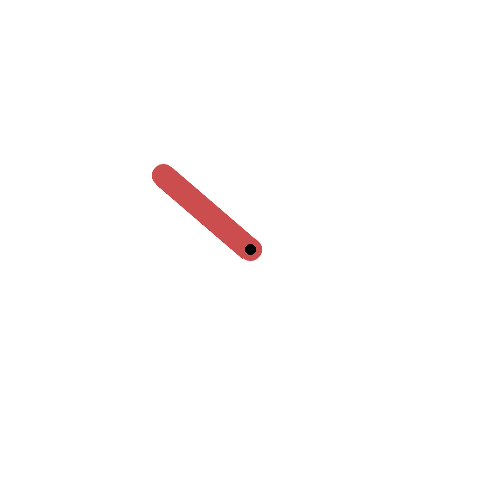

In [7]:
shots = record_episode(sb3_policy(sac_model), seed=0, every=3)
print("エピソードのステップ数:", shots[-1][0])
imageio.v3.imwrite(FIGURES / "ch10_sac.gif", [frame for _, frame in shots], duration=100, loop=0)
print("GIF の枚数:", len(shots))
Image(filename=FIGURES / "ch10_sac.gif")

**期待する結果**（上の出力の読み方）: Pendulum は 200 ステップで打ち切られるので、エピソードのステップ数は 200 です。GIF には、最初の絵と 3 ステップごとの絵 66 枚と、最後の 200 ステップ目の絵の、合わせて 68 枚を書き込みます。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、5-3節の GIF です。振り子は左上に傾いた向きから始まり、いったん右下へ振れたあと、勢いをつけて真上の近くまで振り上がります。そのあとは最後まで、真上から少し右に傾いた位置で、ほぼ止まっています。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じエピソードのコマ送りの図を作ります。

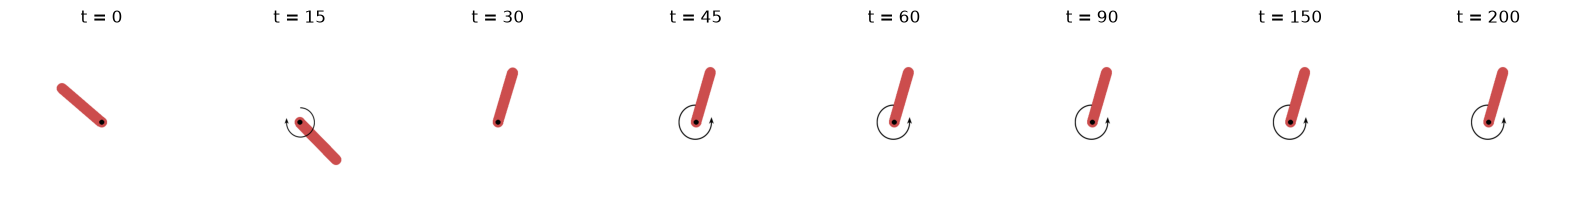

In [8]:
picks = [0, 5, 10, 15, 20, 30, 50, len(shots) - 1]  # 振り上げの間は細かく、そのあとは粗く選ぶ
fig, axes = plt.subplots(1, len(picks), figsize=(16, 2.4))
for ax, i in zip(axes, picks):
    t, frame = shots[i]
    ax.imshow(frame[50:450, 50:450])
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch10_sac_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 5-3節のエピソードから選んだ 8 枚（t = 0、15、30、45、60、90、150、200）です。t = 0 では左上に傾き、t = 15 では右下に垂れています。t = 30 では真上の近くまで振り上がり、t = 45 から t = 200 までは、真上から少し右に傾いた同じ位置にいます。軸のまわりの矢印は、直前にかけたトルクを表す描画で、トルクが大きいほど大きく描かれます（Gymnasium 1.3.0 の `pendulum.py` の描画処理）。

## 6. 読む：PyTorch の DDPG のサンプル

SAC・TD3 のもとになった、もっとも基本的な手法 **DDPG**（Deep Deterministic Policy Gradient）を、PyTorch で短く書いたサンプルを動かして、読みます。設定は著者が決めた値です（10,000 ステップ、学習率 0.001、γ = 0.98、ネットワークは Actor・Critic とも 256 × 256）。第7章の6節と同じく、学習中にときどき 10 回遊ばせて評価し、一番よい時点の Actor を残します（評価の間隔は、第7章の 2,500 ステップではなく、1,000 ステップごとです）。著者の環境では 95 秒ほどかかりました。

In [9]:
# Actor：観測3つ → トルク1つ（Tanh で -1〜1 にしてから、2 倍して -2〜2 にする）
def make_actor():
    return nn.Sequential(nn.Linear(3, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1), nn.Tanh())


# Critic：観測3つとトルク1つ → その行動の Q 値1つ
def make_critic():
    return nn.Sequential(nn.Linear(4, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))


# Actor が出すトルクを、そのまま選ぶ方策（観測 → 行動）を返す
def actor_policy(actor):
    def policy(observation):
        with torch.no_grad():
            return 2.0 * actor(torch.as_tensor(observation)).numpy()
    return policy


# DDPG で total_steps ステップ学習させる。noise は探索のために行動に足すノイズの標準偏差
# 学習後の Actor と、1,000 ステップごとの評価で一番よかった時点の Actor と、評価の記録（ステップ数, 平均）の一覧を返す
def ddpg(total_steps=10_000, lr=1e-3, gamma=0.98, tau=0.005, noise=0.2, batch_size=256, learning_starts=1000, seed=0):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = make_pendulum()
    env.action_space.seed(seed)
    actor, critic = make_actor(), make_critic()
    target_actor, target_critic = copy.deepcopy(actor), copy.deepcopy(critic)  # ターゲットネットワーク
    actor_optimizer = torch.optim.Adam(actor.parameters(), lr=lr)
    critic_optimizer = torch.optim.Adam(critic.parameters(), lr=lr)
    # リプレイバッファ（全ステップ分の場所を先に用意する）
    observations = np.zeros((total_steps, 3), dtype=np.float32)
    actions = np.zeros((total_steps, 1), dtype=np.float32)
    rewards = np.zeros(total_steps, dtype=np.float32)
    next_observations = np.zeros((total_steps, 3), dtype=np.float32)
    dones = np.zeros(total_steps, dtype=np.float32)
    best_actor, best_score, evals = copy.deepcopy(actor), -np.inf, []
    observation, info = env.reset(seed=seed)
    for t in range(total_steps):
        # 1. 行動を選ぶ：はじめはでたらめに、そのあとは Actor のトルクにノイズを足す
        if t < learning_starts:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = 2.0 * actor(torch.as_tensor(observation)).numpy()
            action = np.clip(action + rng.normal(0.0, noise, size=1), -2.0, 2.0).astype(np.float32)
        next_observation, reward, terminated, truncated, info = env.step(action)
        observations[t], actions[t], rewards[t] = observation, action, reward
        next_observations[t], dones[t] = next_observation, terminated
        observation = next_observation
        if terminated or truncated:
            observation, info = env.reset()
        if t >= learning_starts:
            # 2. リプレイバッファから batch_size 個の経験を選ぶ
            idx = rng.integers(0, t + 1, size=batch_size)
            s, a, r, s2, d = (torch.as_tensor(x[idx]) for x in (observations, actions, rewards, next_observations, dones))
            # 3. Critic：目標の Q 値 = 報酬 + γ × ターゲットの Critic(次の観測, ターゲットの Actor のトルク)
            with torch.no_grad():
                next_q = target_critic(torch.cat([s2, 2.0 * target_actor(s2)], dim=1)).squeeze(1)
                target = r + gamma * (1 - d) * next_q
            q = critic(torch.cat([s, a], dim=1)).squeeze(1)
            critic_loss = ((q - target) ** 2).mean()
            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()
            # 4. Actor：Critic が見積もる Q 値が大きくなる向きに、Actor の重みを動かす
            actor_loss = -critic(torch.cat([s, 2.0 * actor(s)], dim=1)).mean()
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()
            # 5. ターゲットネットワークを、今のネットワークに少しずつ（tau の割合で）近づける
            with torch.no_grad():
                for net, target_net in ((actor, target_actor), (critic, target_critic)):
                    for p, target_p in zip(net.parameters(), target_net.parameters()):
                        target_p.mul_(1 - tau).add_(tau * p)
        # 1,000 ステップごとに 10 回遊ばせて評価し、一番よい時点の Actor を残す
        if (t + 1) % 1000 == 0:
            score, _ = evaluate(actor_policy(actor), episodes=10, seed=200 + t + 1)
            evals.append((t + 1, score))
            if score > best_score:
                best_actor, best_score = copy.deepcopy(actor), score
    return actor, best_actor, evals


start = time.perf_counter()
actor, best_actor, ddpg_evals = ddpg()
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print("1,000 ステップごとの評価（10 回の平均）:", np.round([score for _, score in ddpg_evals], 1))
for name, a in [("最後の時点", actor), ("一番よい時点", best_actor)]:
    mean, std = evaluate(actor_policy(a))
    print(f"{name}の Actor: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

学習にかかった時間: 94 秒
1,000 ステップごとの評価（10 回の平均）: [-1466.3 -1378.2  -823.6  -167.8  -195.1  -172.6  -174.7  -133.6  -201.9
  -123.1]


最後の時点の Actor: 報酬の合計の平均 -162.2、標準偏差 86.5


一番よい時点の Actor: 報酬の合計の平均 -162.2、標準偏差 86.5


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 94 秒でした。1,000 ステップごとの評価（10 回の平均）は、1,000〜3,000 ステップでは -823.6〜-1466.3 で、4,000 ステップで -167.8 に上がりました。そのあとは -123.1〜-201.9 の間を上下しています。最後の時点の Actor と一番よい時点の Actor は、どちらも平均 -162.2（標準偏差 86.5）で、同じ値です。評価が一番よかったのが、最後の 10,000 ステップの時点（-123.1）だったためです。

著者が学習の seed を 0〜4 に変えて測ったところ、最後の時点の Actor は -160.7〜-163.9 で、どの seed でも -200 を超えました。どの seed でも、一番よかった評価は最後の 10,000 ステップの時点で、最後の時点と一番よい時点は同じ Actor でした。この評価（10 回）では、時点ごとに、遊ばせる 10 回の始まり方（`seed=200 + ステップ数`）が決まっています。著者が見たところ、同じ時点の評価の値は、学習の seed が違ってもほとんど同じでした（10,000 ステップでは、seed 0〜4 で -123〜-125）。

### 6-1. Actor が行動を直接出す

```python
action = 2.0 * actor(torch.as_tensor(observation)).numpy()
action = np.clip(action + rng.normal(0.0, noise, size=1), -2.0, 2.0).astype(np.float32)
```

第7章の DQN のネットワークは行動ごとの Q 値を出し、その中から一番大きい行動を選びました。DDPG の **Actor** は、観測を受け取って、トルクの値そのものを1つ出します。行動の数を数え上げる必要が無いので、連続の値の行動を扱えます。最後の `Tanh` で -1〜1 にしてから 2 倍して、Pendulum のトルクの範囲（-2〜2）に合わせています。

Actor が出す行動は、同じ観測なら毎回同じです（**決定的な方策**。DDPG の「D」は Deterministic、決定的の意味です）。それだけでは同じ行動しか試さないので、学習中は、標準偏差 `noise`（0.2）の正規分布のノイズを足して探索します。DQN の ε-greedy の代わりです。

### 6-2. Critic の損失（DQN と同じ形）

```python
with torch.no_grad():
    next_q = target_critic(torch.cat([s2, 2.0 * target_actor(s2)], dim=1)).squeeze(1)
    target = r + gamma * (1 - d) * next_q
q = critic(torch.cat([s, a], dim=1)).squeeze(1)
critic_loss = ((q - target) ** 2).mean()
```

**Critic** は、観測と行動を受け取って、その Q 値を1つ出します。損失の形は、第7章の DQN と同じ「目標の Q 値とのずれの2乗」です。違うのは、目標の中の「次の観測での一番よい行動」です。DQN は、行動ごとの Q 値の最大値（`max`）を使いました。DDPG は、行動を数え上げられないので、ターゲットの Actor が出すトルクを、次の観測での一番よい行動とみなして使います。

`(1 - d)` は、エピソードが途中で終わった（`terminated`）ときに、その先の Q 値を 0 にするためのものです。Pendulum は打ち切り（`truncated`）でしか終わらないので、`d` はいつも 0 で、打ち切りのときも次の観測の Q 値で続きを見積もります。

### 6-3. Actor の損失（Critic の見積もりを上げる）

```python
actor_loss = -critic(torch.cat([s, 2.0 * actor(s)], dim=1)).mean()
```

Actor が出したトルクを Critic に渡し、その Q 値の符号を逆にしたものを損失にします。この損失を小さくする向き（＝ Q 値を大きくする向き）に、Actor の重みだけを動かします（`actor_optimizer` は Actor の重みしか持っていません）。「Critic が、もっと Q 値が大きくなると見積もるトルク」へ、Actor の出す値を少しずつずらしていくことになります。

### 6-4. ターゲットネットワークを少しずつ近づける

```python
target_p.mul_(1 - tau).add_(tau * p)
```

第7章の DQN のサンプルは、ターゲットネットワークを、決まったステップごとに丸ごと写しました。DDPG では、毎ステップ、ターゲットネットワークの重みを「(1 - tau) × 自分 + tau × 今のネットワーク」に置き換えて、少しずつ（tau = 0.005 の割合で）近づけます。目標の Q 値が急に変わらないようにする、という目的は同じです。

### 6-5. SB3 の TD3・SAC との関係

SB3 の `DDPG` は、`TD3` の設定を変えたものとして作られています（SB3 2.9.0 の `stable_baselines3/ddpg/ddpg.py`）。TD3 は、DDPG に次の工夫を足した手法です（SB3 2.9.0 の `stable_baselines3/td3/td3.py` と `stable_baselines3/td3/policies.py` の既定値）。

- Critic を2つ持ち、目標の Q 値には、2つの見積もりの小さいほうを使う
- Actor とターゲットネットワークの更新を、Critic の更新の2回に1回にする（`policy_delay=2`）
- 目標の Q 値を計算するときの、ターゲットの Actor のトルクにも、ノイズを足す（`target_policy_noise=0.2`）

SAC は、Actor が決定的な値ではなく、**トルクの確率の分布** を出す手法です。学習中は、その分布から行動を選んで探索します。評価や GIF では、`deterministic=True` で、分布の真ん中の値を選びました。SAC の Actor の損失には、分布が広い（いろいろな行動を選ぶ）ほど得をする項（エントロピー）が入っていて、その重みも自動で調整されます（SB3 の既定の `ent_coef="auto"`）。

## 7. 比べる：SAC・TD3・DDPG・区切った DQN

4節の DQN、5節の SAC、6節の DDPG のサンプルの、学習中の評価（10 回の平均）を並べます。

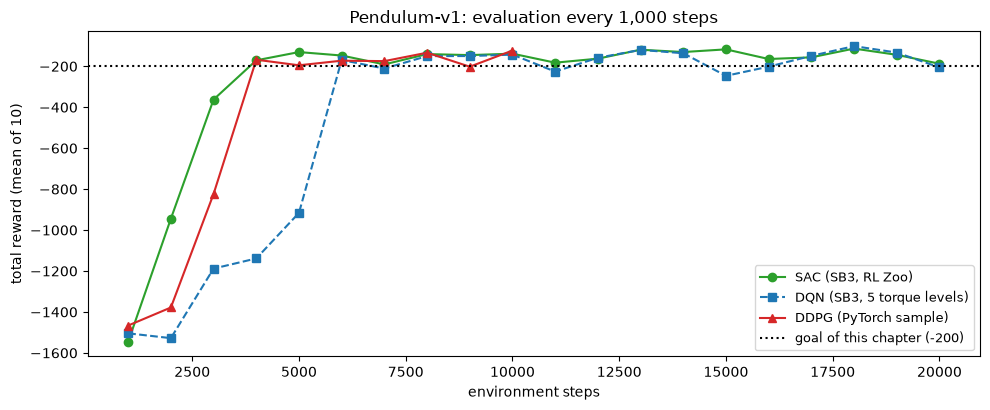

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(sac_callback.evaluations_timesteps, sac_evals, "o-", color="tab:green", label="SAC (SB3, RL Zoo)")
ax.plot(dqn_callback.evaluations_timesteps, np.mean(dqn_callback.evaluations_results, axis=1), "s--", color="tab:blue",
        label=f"DQN (SB3, {N_TORQUES} torque levels)")
ddpg_steps, ddpg_scores = zip(*ddpg_evals)
ax.plot(ddpg_steps, ddpg_scores, "^-", color="tab:red", label="DDPG (PyTorch sample)")
ax.axhline(-200, color="black", linestyle=":", label="goal of this chapter (-200)")
ax.set_xlabel("environment steps")
ax.set_ylabel("total reward (mean of 10)")
ax.set_title("Pendulum-v1: evaluation every 1,000 steps")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "ch10_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 緑の丸が SAC（5節）、青い四角の破線がトルクを 5 段階に区切った DQN（4節）、赤い三角が DDPG のサンプル（6節）の、1,000 ステップごとの評価です。黒い点線が、この章の目安の -200 です。SAC と DDPG のサンプルは 4,000 ステップで、DQN は 6,000 ステップで、-200 の近くまで上がりました。そのあとは、3つとも -100〜-250 ほどの間で、重なり合いながら上下しています。

著者が学習の seed を 0〜4 に変えて測った値を並べます（評価はこの Notebook の `evaluate` と同じ 100 回）。SB3 の TD3・DDPG は、RL Zoo の Pendulum-v1 用の値（2つとも同じ値で、20,000 ステップ、γ 0.98、学習を始める前のでたらめな行動 10,000 ステップ、行動に足すノイズの標準偏差 0.1、ネットワーク 400 × 300 ほか）で、この Notebook では実行していません。

| 手法 | 節 | 学習のステップ数 | 最後の時点の平均（seed 0〜4） |
|---|---|---|---|
| SAC（SB3、RL Zoo の値） | 5節 | 20,000 | -155.2〜-166.0 |
| TD3（SB3、RL Zoo の値） | （実行していない） | 20,000 | -159.4〜-162.3 |
| DDPG（SB3、RL Zoo の値） | （実行していない） | 20,000 | -157.9〜-165.0 |
| DQN（SB3、トルク 5 段階、著者の値） | 4節 | 20,000 | -161.4〜-168.8 |
| DDPG（PyTorch のサンプル、著者の値） | 6節 | 10,000 | -160.7〜-163.9 |

どの手法も、どの seed でも -200 を超え、平均は -155〜-169 ほどの狭い範囲に入りました。この表の範囲では、手法の違いによる成績の差は、seed による違いと同じくらいの大きさです。学習のステップ数も、ネットワークの大きさなどの設定も、手法ごとに違うので、この表から、どの手法が優れているかは言えません。

## 8. 遊んでみる

**やってみよう**:

- 4節のセルの `N_TORQUES` を 2 や 11 に変えてみてください（著者が seed 0〜4 で測った値は4節の表のとおりです）
- 6節の `ddpg()` に `noise=0.0` を渡して、探索のノイズを外してみてください。著者が seed 0〜4 で試したところ、最後の時点の Actor は -160.2〜-163.6 で、ノイズを足したとき（-160.7〜-163.9）とほとんど同じでした。はじめの 1,000 ステップのでたらめな行動のおかげかどうかは、確かめていません
- 6節の `ddpg()` の `tau` や `total_steps` を変えてみてください。著者が seed 0 で `total_steps=20_000` を試したところ、最後の時点の Actor は -156.6 でした
- 5節の `SAC(...)` の `learning_rate=1e-3` を外して、SB3 の既定値（0.0003）で学習させてみてください（著者は確かめていません）
- 2節の `make_pendulum` の中の `gym.make("Pendulum-v1")` に `g=9.81`（重力の加速度。既定は 10.0）を渡すと、少し軽い重力の振り子になります（Gymnasium 1.3.0 の `pendulum.py` の説明）。この関数を使うすべての節に効きます

## 9. まとめ

この章では、行動が連続の値の Pendulum を解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 観測・行動・報酬を確かめ、でたらめな行動で遊ぶ | `env.action_space`（`Box`） | 3節 |
| トルクを区切って DQN で解く | `gym.ActionWrapper`、`DQN` | 4節 |
| SB3 の SAC を RL Zoo の値で学習させる | `SAC`、`EvalCallback` | 5節 |
| PyTorch の DDPG のサンプルを読む | `ddpg()`、Actor、Critic | 6節 |
| SAC・TD3・DDPG・区切った DQN を並べる | seed 0〜4 の値 | 7節 |

行動が連続の値の Pendulum では、DQN のように行動ごとの Q 値を並べることが、そのままではできませんでした。トルクを区切れば DQN でも解けて、この章の範囲（2〜11 段階）では、段階の数による大きな差はありませんでした。ただし、行動が複数の値の組になると、区切った行動の数は掛け算で増えます。SAC・TD3・DDPG は、行動を出す Actor と、観測と行動から Q 値を見積もる Critic を組み合わせ、行動を数え上げずに学習します。DDPG のサンプルでは、Critic は DQN と同じ形の損失で、Actor は Critic の見積もりが大きくなる向きに学びました。この章の設定では、どの手法も、どの seed でも -200 を超えました。

- 次に読むもの: 第11章 LunarLander（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第11章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0・Stable-Baselines3 2.9.0 のソースと動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。PyTorch のサンプルのコードは著者が書いたものです。

- T. P. Lillicrap et al., "Continuous control with deep reinforcement learning", *International Conference on Learning Representations (ICLR)*, 2016（DDPG）
- S. Fujimoto, H. van Hoof, D. Meger, "Addressing function approximation error in actor-critic methods", *Proceedings of the 35th International Conference on Machine Learning (ICML)*, 2018（TD3）
- T. Haarnoja, A. Zhou, P. Abbeel, S. Levine, "Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor", *Proceedings of the 35th International Conference on Machine Learning (ICML)*, 2018（SAC）
- RL Baselines3 Zoo, v2.9.0 の `hyperparams/sac.yml`・`hyperparams/td3.yml`・`hyperparams/ddpg.yml`（Pendulum-v1 のハイパーパラメータ）: https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/sac.yml 、https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/td3.yml 、https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/ddpg.yml
- Stable-Baselines3 のソース（v2.9.0。`stable_baselines3/sac/sac.py`・`stable_baselines3/td3/td3.py`・`stable_baselines3/td3/policies.py`・`stable_baselines3/ddpg/ddpg.py` の既定値）: https://github.com/DLR-RM/stable-baselines3/tree/v2.9.0/stable_baselines3
- Gymnasium 1.3.0 のソース（導入したパッケージの中の `gymnasium/envs/classic_control/pendulum.py` の環境の説明と報酬の式、`gymnasium/envs/__init__.py` の登録）

5節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の Pendulum の描画処理が出力したものです。グラフは、著者が matplotlib で描いたものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。